In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import spacy

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ All libraries loaded successfully!


In [2]:
# Load the resume dataset
df = pd.read_csv('resume_data.csv')

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nJob Categories Available:")
print(df['Category'].value_counts())
print("\nFirst row preview:")
df.head(2)

Shape: (2484, 4)

Column Names:
['ID', 'Resume_str', 'Resume_html', 'Category']

Job Categories Available:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

First row preview:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# We will screen resumes for a DATA SCIENTIST role
# You can change this to any role you want

JOB_ROLE = "Data Scientist"

JOB_DESCRIPTION = """
We are looking for an experienced Data Scientist with strong 
skills in Python, machine learning, deep learning, NLP, 
data analysis, pandas, numpy, scikit-learn, TensorFlow, 
statistics, data visualization, matplotlib, seaborn, 
SQL, feature engineering, model evaluation, neural networks,
regression, classification, clustering, and problem solving.
Experience with big data, cloud platforms and research is a plus.
"""

print(f"✅ Job Role: {JOB_ROLE}")
print(f"\nJob Description Preview:")
print(JOB_DESCRIPTION[:300])

✅ Job Role: Data Scientist

Job Description Preview:

We are looking for an experienced Data Scientist with strong 
skills in Python, machine learning, deep learning, NLP, 
data analysis, pandas, numpy, scikit-learn, TensorFlow, 
statistics, data visualization, matplotlib, seaborn, 
SQL, feature engineering, model evaluation, neural networks,
regressi


In [4]:
# Filter only Data Scientist resumes
# and a few others to compare against
target_df = df[df['Category'] == JOB_ROLE].copy()
other_df = df[df['Category'] != JOB_ROLE].sample(
    min(20, len(df[df['Category'] != JOB_ROLE])),
    random_state=42
).copy()

# Combine them
screening_df = pd.concat([target_df.head(30), other_df], 
                          ignore_index=True)

# Create candidate names
screening_df['candidate_name'] = [
    f"Candidate_{i+1:03d}" for i in range(len(screening_df))
]

print(f"✅ Resumes loaded for screening!")
print(f"Total resumes to screen: {len(screening_df)}")
print(f"\nRole breakdown:")
print(screening_df['Category'].value_counts())

✅ Resumes loaded for screening!
Total resumes to screen: 20

Role breakdown:
Category
TEACHER                 2
BANKING                 2
BUSINESS-DEVELOPMENT    2
DESIGNER                2
HEALTHCARE              2
SALES                   2
ARTS                    2
DIGITAL-MEDIA           1
CONSTRUCTION            1
CHEF                    1
AUTOMOBILE              1
ADVOCATE                1
HR                      1
Name: count, dtype: int64


In [5]:
stop_words = set(stopwords.words('english'))

def clean_resume_text(text):
    # Convert to string
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove phone numbers
    text = re.sub(r'\b\d{10}\b|\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '', text)
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Lowercase
    text = text.lower()
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    return ' '.join(words)

# Apply cleaning
screening_df['clean_resume'] = screening_df['Resume'].apply(clean_resume_text)

print("✅ All resumes cleaned!")
print(f"\nBefore cleaning (length): {len(screening_df['Resume'].iloc[0])}")
print(f"After cleaning (length) : {len(screening_df['clean_resume'].iloc[0])}")
print("\nSample cleaned text (first 200 chars):")
print(screening_df['clean_resume'].iloc[0][:200])

KeyError: 'Resume'

In [10]:
# Check exact column names
print("Exact columns in your dataset:")
print(df.columns.tolist())
print("\nFirst row:")
print(df.head(1))


Exact columns in your dataset:
['ID', 'Resume_str', 'Resume_html', 'Category']

First row:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  


In [11]:
# Your columns are:
# 'ID', 'Resume_str', 'Resume_html', 'Category'

resume_col = 'Resume_str'
category_col = 'Category'

print(f"✅ Resume column   : '{resume_col}'")
print(f"✅ Category column : '{category_col}'")
print(f"\nCategories available:")
print(df[category_col].value_counts())

✅ Resume column   : 'Resume_str'
✅ Category column : 'Category'

Categories available:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [12]:
stop_words = set(stopwords.words('english'))

def clean_resume_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d{10}\b|\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Check if JOB_ROLE exists in dataset
print("Available categories:")
print(df[category_col].unique().tolist())
print(f"\nLooking for: '{JOB_ROLE}'")

# Check if our job role exists
if JOB_ROLE in df[category_col].values:
    target_df = df[df[category_col] == JOB_ROLE].copy()
    print(f"✅ Found {len(target_df)} resumes for {JOB_ROLE}")
else:
    # Pick the first available category
    JOB_ROLE = df[category_col].value_counts().index[0]
    target_df = df[df[category_col] == JOB_ROLE].copy()
    print(f"⚠️  'Data Scientist' not found!")
    print(f"✅ Using '{JOB_ROLE}' instead ({len(target_df)} resumes)")

# Get other category resumes to compare
other_df = df[df[category_col] != JOB_ROLE].sample(
    min(20, len(df[df[category_col] != JOB_ROLE])),
    random_state=42
).copy()

# Combine
screening_df = pd.concat(
    [target_df.head(30), other_df],
    ignore_index=True
)

# Add candidate names
screening_df['candidate_name'] = [
    f"Candidate_{i+1:03d}" for i in range(len(screening_df))
]

# Clean resume text
screening_df['clean_resume'] = screening_df[resume_col].apply(
    clean_resume_text
)

print(f"\n✅ Data ready!")
print(f"Total resumes to screen : {len(screening_df)}")
print(f"Target role resumes     : {len(target_df.head(30))}")
print(f"Other role resumes      : {len(other_df)}")
print(f"\nSample cleaned text:")
print(screening_df['clean_resume'].iloc[0][:200])

Available categories:
['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE', 'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE', 'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE', 'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']

Looking for: 'Data Scientist'
⚠️  'Data Scientist' not found!
✅ Using 'INFORMATION-TECHNOLOGY' instead (120 resumes)

✅ Data ready!
Total resumes to screen : 50
Target role resumes     : 30
Other role resumes      : 20

Sample cleaned text:
information technology summary dedicated information assurance professional well versed analyzing mitigating risk finding cost effective solutions excels boosting performance productivity establishing


In [13]:
SKILLS_LIST = [
    'python', 'java', 'javascript', 'sql', 'r', 'scala',
    'machine learning', 'deep learning', 'neural networks', 'nlp',
    'natural language processing', 'computer vision', 'tensorflow',
    'keras', 'pytorch', 'scikit-learn', 'xgboost',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'tableau',
    'power bi', 'excel', 'statistics', 'data analysis',
    'data visualization', 'feature engineering',
    'regression', 'classification', 'clustering', 'random forest',
    'decision tree', 'svm', 'logistic regression',
    'aws', 'azure', 'docker', 'git', 'github',
    'jupyter', 'spark', 'hadoop', 'mongodb', 'mysql',
    'communication', 'teamwork', 'problem solving', 'research',
    # HR specific (since your dataset has HR category)
    'recruitment', 'hiring', 'hr', 'payroll', 'onboarding',
    'training', 'performance management', 'employee relations',
    'talent acquisition', 'workforce planning'
]

def extract_skills(text):
    text_lower = str(text).lower()
    return [skill for skill in SKILLS_LIST if skill in text_lower]

screening_df['extracted_skills'] = screening_df['clean_resume'].apply(
    extract_skills
)
screening_df['skill_count'] = screening_df['extracted_skills'].apply(len)

print("✅ Skills extracted!")
print(f"\nSkills found in Candidate_001:")
print(screening_df['extracted_skills'].iloc[0])
print(f"Total skills: {screening_df['skill_count'].iloc[0]}")


✅ Skills extracted!

Skills found in Candidate_001:
['r', 'excel', 'communication', 'hr', 'training']
Total skills: 5


In [14]:
clean_jd = clean_resume_text(JOB_DESCRIPTION)

all_texts = [clean_jd] + screening_df['clean_resume'].tolist()

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)
tfidf_matrix = vectorizer.fit_transform(all_texts)

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)[0]

screening_df['match_score'] = similarity_scores
screening_df['match_percent'] = (similarity_scores * 100).round(2)

screening_df = screening_df.sort_values(
    'match_score', ascending=False
).reset_index(drop=True)
screening_df['rank'] = range(1, len(screening_df) + 1)

print("✅ All candidates ranked!")
print("\nTop 10 Candidates:")
print("=" * 58)
print(screening_df[[
    'rank', 'candidate_name',
    category_col, 'match_percent',
    'skill_count'
]].head(10).to_string(index=False))

✅ All candidates ranked!

Top 10 Candidates:
 rank candidate_name               Category  match_percent  skill_count
    1  Candidate_027 INFORMATION-TECHNOLOGY          10.23            5
    2  Candidate_001 INFORMATION-TECHNOLOGY          10.15            5
    3  Candidate_004 INFORMATION-TECHNOLOGY           9.88            6
    4  Candidate_017 INFORMATION-TECHNOLOGY           8.32            6
    5  Candidate_013 INFORMATION-TECHNOLOGY           7.22            5
    6  Candidate_042                FINANCE           6.78            6
    7  Candidate_014 INFORMATION-TECHNOLOGY           6.49            7
    8  Candidate_047             ACCOUNTANT           6.38            7
    9  Candidate_026 INFORMATION-TECHNOLOGY           5.78            5
   10  Candidate_019 INFORMATION-TECHNOLOGY           5.26            7


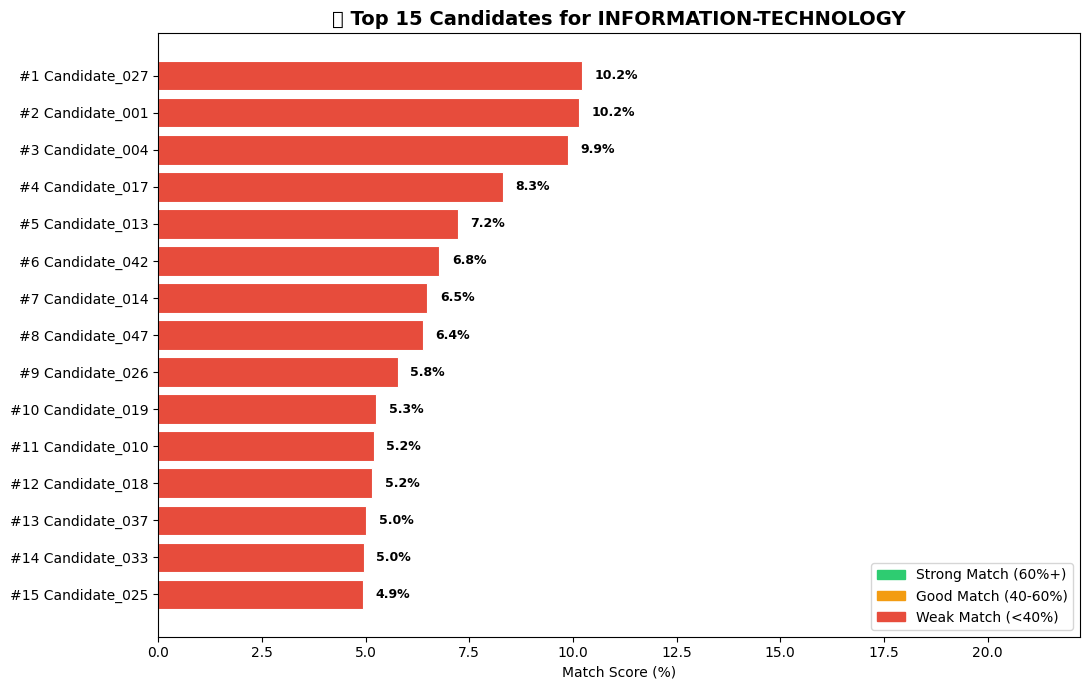

✅ Rankings chart saved!


In [15]:
top15 = screening_df.head(15)

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = []
for score in top15['match_percent']:
    if score >= 60:
        bar_colors.append('#2ecc71')
    elif score >= 40:
        bar_colors.append('#f39c12')
    else:
        bar_colors.append('#e74c3c')

bars = ax.barh(
    [f"#{r} {n}" for r, n in
     zip(top15['rank'], top15['candidate_name'])],
    top15['match_percent'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar, score in zip(bars, top15['match_percent']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2.,
            f'{score:.1f}%', va='center',
            fontsize=9, fontweight='bold')

ax.set_xlabel('Match Score (%)')
ax.set_title(f'🏆 Top 15 Candidates for {JOB_ROLE}',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top15['match_percent']) + 12)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Strong Match (60%+)'),
    Patch(color='#f39c12', label='Good Match (40-60%)'),
    Patch(color='#e74c3c', label='Weak Match (<40%)')
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('candidate_rankings.png', dpi=150)
plt.show()
print("✅ Rankings chart saved!")

In [16]:
jd_skills = extract_skills(JOB_DESCRIPTION)

print(f"📋 Required Skills for {JOB_ROLE}:")
print(f"   {jd_skills}")
print(f"\nTotal required: {len(jd_skills)}")
print("\n" + "=" * 60)
print("SKILL GAP ANALYSIS — TOP 10 CANDIDATES")
print("=" * 60)

for _, row in screening_df.head(10).iterrows():
    candidate_skills = row['extracted_skills']
    matched = [s for s in jd_skills if s in candidate_skills]
    missing = [s for s in jd_skills if s not in candidate_skills]
    skill_match = (len(matched)/len(jd_skills)*100
                   if jd_skills else 0)

    print(f"\n👤 {row['candidate_name']} "
          f"(Rank #{row['rank']}, "
          f"Score: {row['match_percent']}%)")
    print(f"   ✅ Has    : "
          f"{', '.join(matched) if matched else 'None'}")
    print(f"   ❌ Missing: "
          f"{', '.join(missing[:5]) if missing else 'All present!'}")
    print(f"   📊 Skill Match: {skill_match:.1f}%")

📋 Required Skills for INFORMATION-TECHNOLOGY:
   ['python', 'sql', 'r', 'machine learning', 'deep learning', 'neural networks', 'nlp', 'tensorflow', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'statistics', 'data analysis', 'data visualization', 'feature engineering', 'regression', 'classification', 'clustering', 'problem solving', 'research']

Total required: 22

SKILL GAP ANALYSIS — TOP 10 CANDIDATES

👤 Candidate_027 (Rank #1, Score: 10.23%)
   ✅ Has    : sql, r, research
   ❌ Missing: python, machine learning, deep learning, neural networks, nlp
   📊 Skill Match: 13.6%

👤 Candidate_001 (Rank #2, Score: 10.15%)
   ✅ Has    : r
   ❌ Missing: python, sql, machine learning, deep learning, neural networks
   📊 Skill Match: 4.5%

👤 Candidate_004 (Rank #3, Score: 9.88%)
   ✅ Has    : r, data analysis, problem solving
   ❌ Missing: python, sql, machine learning, deep learning, neural networks
   📊 Skill Match: 13.6%

👤 Candidate_017 (Rank #4, Score: 8.32%)
   ✅ Has    : r, d

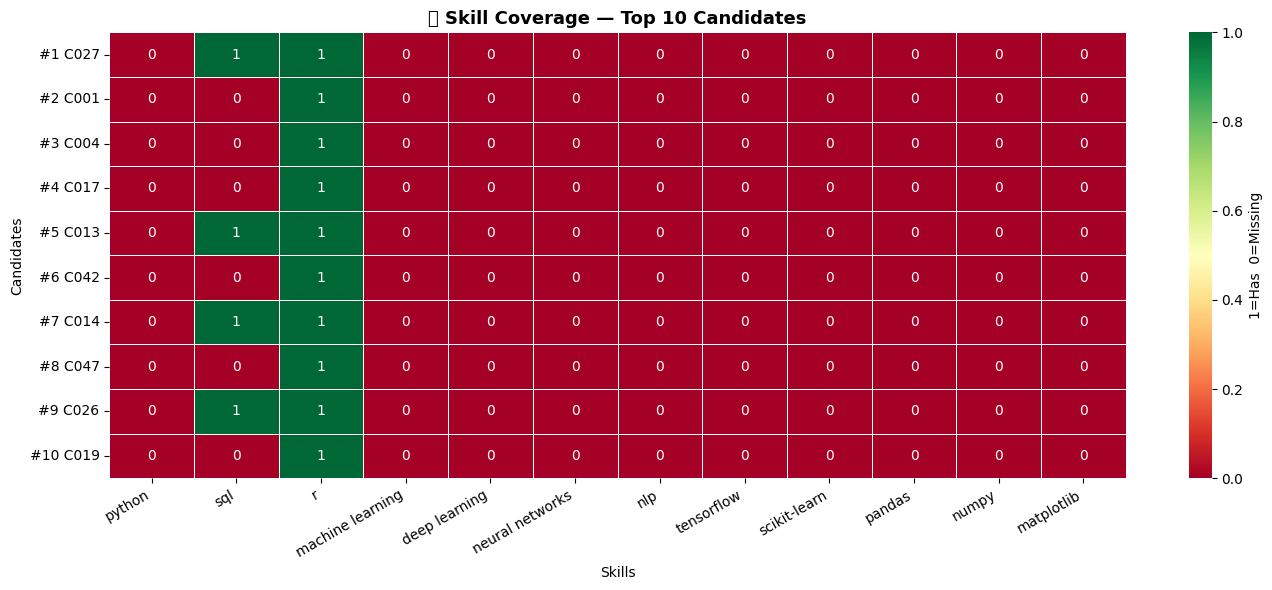

✅ Heatmap saved!


In [17]:
key_skills = jd_skills[:12] if len(jd_skills) >= 12 else jd_skills

# If no JD skills found, use top skills from resumes
if len(key_skills) == 0:
    all_skills_flat = [s for skills in
                       screening_df['extracted_skills']
                       for s in skills]
    from collections import Counter
    top_skills = Counter(all_skills_flat).most_common(10)
    key_skills = [s[0] for s in top_skills]
    print(f"⚠️  Using top resume skills: {key_skills}")

top10_names = [
    f"#{r} C{n.split('_')[1]}"
    for r, n in zip(
        screening_df.head(10)['rank'],
        screening_df.head(10)['candidate_name']
    )
]

skill_matrix = []
for _, row in screening_df.head(10).iterrows():
    candidate_skills = row['extracted_skills']
    row_data = [1 if skill in candidate_skills else 0
                for skill in key_skills]
    skill_matrix.append(row_data)

skill_df = pd.DataFrame(
    skill_matrix,
    index=top10_names,
    columns=key_skills
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    skill_df, annot=True, cmap='RdYlGn',
    linewidths=0.5, fmt='d',
    cbar_kws={'label': '1=Has  0=Missing'},
    vmin=0, vmax=1
)
plt.title('🔍 Skill Coverage — Top 10 Candidates',
          fontsize=13, fontweight='bold')
plt.xlabel('Skills')
plt.ylabel('Candidates')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('skill_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

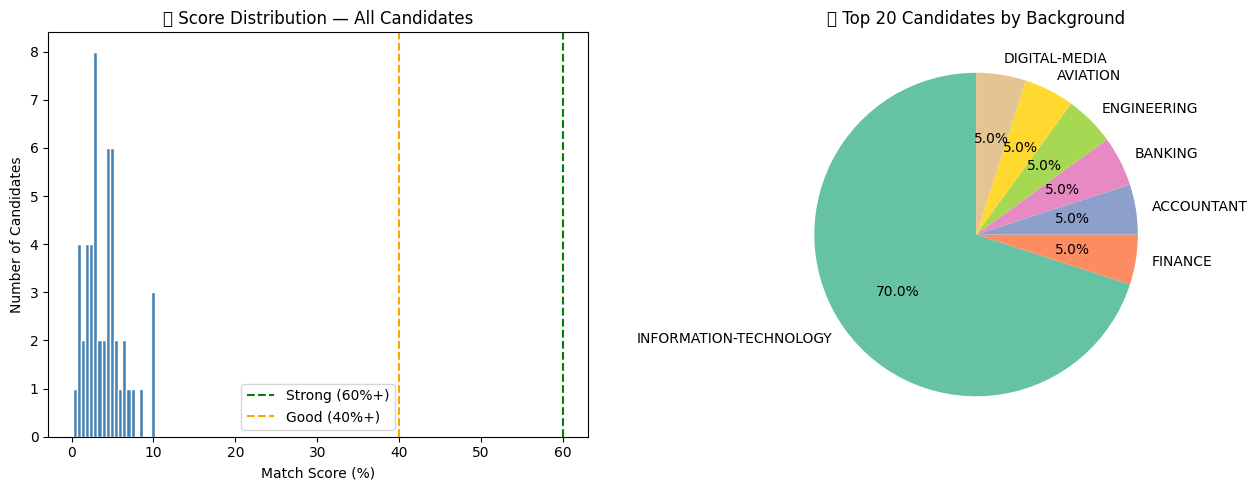

✅ Distribution chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(screening_df['match_percent'],
             bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=60, color='green', linestyle='--',
                label='Strong (60%+)')
axes[0].axvline(x=40, color='orange', linestyle='--',
                label='Good (40%+)')
axes[0].set_title('📊 Score Distribution — All Candidates')
axes[0].set_xlabel('Match Score (%)')
axes[0].set_ylabel('Number of Candidates')
axes[0].legend()

top20_cats = screening_df.head(20)[category_col].value_counts()
colors = sns.color_palette('Set2', len(top20_cats))
axes[1].pie(top20_cats.values,
            labels=top20_cats.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('🥧 Top 20 Candidates by Background')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()
print("✅ Distribution chart saved!")

In [19]:
print("=" * 60)
print(f"     🎯 FINAL HIRING REPORT — {JOB_ROLE}")
print("=" * 60)

total = len(screening_df)
strong = len(screening_df[screening_df['match_percent'] >= 60])
good = len(screening_df[
    (screening_df['match_percent'] >= 40) &
    (screening_df['match_percent'] < 60)])
weak = len(screening_df[screening_df['match_percent'] < 40])

print(f"\n📊 Screening Summary:")
print(f"   Total Screened          : {total}")
print(f"   🟢 Strong Matches (60%+): {strong}")
print(f"   🟡 Good Matches (40-60%): {good}")
print(f"   🔴 Weak Matches (<40%)  : {weak}")

print(f"\n🏆 TOP 5 RECOMMENDED:")
print("-" * 60)
for _, row in screening_df.head(5).iterrows():
    skills_p = ', '.join(row['extracted_skills'][:4])
    status = ("🟢 SHORTLIST"
              if row['match_percent'] >= 60
              else "🟡 CONSIDER")
    print(f"\n  #{row['rank']} {row['candidate_name']}")
    print(f"     Score      : {row['match_percent']:.1f}%  {status}")
    print(f"     Background : {row[category_col]}")
    print(f"     Key Skills : {skills_p if skills_p else 'N/A'}")

print(f"\n💡 Recommendations:")
print(f"   1. Interview top {min(strong, 5)} strong match candidates")
print(f"   2. Phone screen the {good} good match candidates")
print(f"   3. Use skill heatmap for interview questions")
print(f"   4. Re-post job if strong matches < 5")

print(f"\n🤖 System Info:")
print(f"   Method  : TF-IDF + Cosine Similarity")
print(f"   Skills  : {len(SKILLS_LIST)} skills tracked")
print(f"   Library : spaCy + scikit-learn")

print("\n" + "=" * 60)
print("✅ Task 3 Complete!")
print("=" * 60)

     🎯 FINAL HIRING REPORT — INFORMATION-TECHNOLOGY

📊 Screening Summary:
   Total Screened          : 50
   🟢 Strong Matches (60%+): 0
   🟡 Good Matches (40-60%): 0
   🔴 Weak Matches (<40%)  : 50

🏆 TOP 5 RECOMMENDED:
------------------------------------------------------------

  #1 Candidate_027
     Score      : 10.2%  🟡 CONSIDER
     Background : INFORMATION-TECHNOLOGY
     Key Skills : sql, r, tableau, research

  #2 Candidate_001
     Score      : 10.2%  🟡 CONSIDER
     Background : INFORMATION-TECHNOLOGY
     Key Skills : r, excel, communication, hr

  #3 Candidate_004
     Score      : 9.9%  🟡 CONSIDER
     Background : INFORMATION-TECHNOLOGY
     Key Skills : r, excel, data analysis, problem solving

  #4 Candidate_017
     Score      : 8.3%  🟡 CONSIDER
     Background : INFORMATION-TECHNOLOGY
     Key Skills : r, excel, data analysis, communication

  #5 Candidate_013
     Score      : 7.2%  🟡 CONSIDER
     Background : INFORMATION-TECHNOLOGY
     Key Skills : sql, r, commun

In [20]:
# Create a smaller version of the dataset
# Only keep 500 rows instead of full dataset

df_small = df.sample(n=500, random_state=42)

# Save as smaller CSV
df_small.to_csv('resume_data_small.csv', index=False)

print(f"✅ Smaller file created!")
print(f"Original size : {len(df)} rows")
print(f"New size      : {len(df_small)} rows")

# Check file size
import os
size = os.path.getsize('resume_data_small.csv')
size_mb = size / (1024 * 1024)
print(f"File size     : {size_mb:.2f} MB")

✅ Smaller file created!
Original size : 2484 rows
New size      : 500 rows
File size     : 11.00 MB


In [21]:
import os

files = [
    'resume_data_small.csv',
    'candidate_rankings.png',
    'skill_heatmap.png',
    'score_distribution.png',
    'Task3_Resume_Screening.ipynb'
]

print("File sizes:")
print("="*40)
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        status = "✅ OK" if size < 25 else "❌ TOO BIG"
        print(f"{f:<35} {size:.2f} MB  {status}")
    else:
        print(f"{f:<35} NOT FOUND")
        

File sizes:
resume_data_small.csv               11.00 MB  ✅ OK
candidate_rankings.png              0.10 MB  ✅ OK
skill_heatmap.png                   0.09 MB  ✅ OK
score_distribution.png              0.09 MB  ✅ OK
Task3_Resume_Screening.ipynb        0.00 MB  ✅ OK
